### The criterion
Run the two code cells **top to bottom** (the second one re-uses the trials simulated in the first). Edit the numbers marked `👈` and re-run to see what changes.

findfont: Failed to find font weight semibold, now using 700.


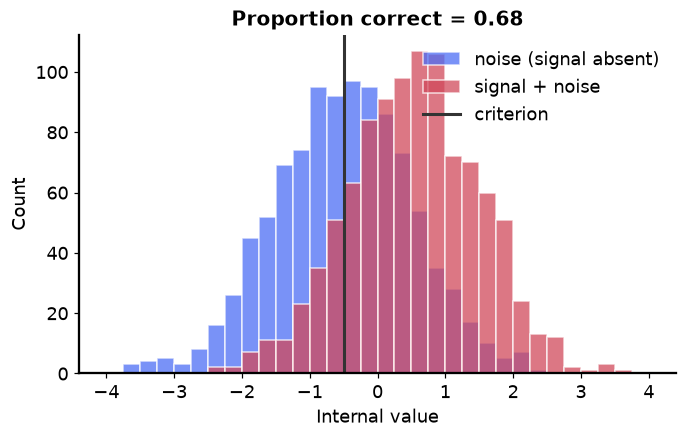

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# plot styling (the Python version of makeMyPlotPretty)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 13,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # signal-absent (noise) trials
SIGNAL = "#d1495b"   # signal-present trials
CRIT   = "#333333"   # the criterion line

# ---- Edit these and re-run --------------------------------------------------
ntrials         = 2000    # number of trials
psignal         = 0.5     # 👈 proportion of signal-present trials
signal_strength = 1       # 👈 how far the signal shifts the experience
criterion       = -0.5    # 👈 the observer reports "yes" above this value
# -----------------------------------------------------------------------------

# each trial the observer's experience is affected by some noise,
# drawn from a gaussian with this mean and standard deviation:
noise_mean = -0.5
noise_sd   = 1

rng = np.random.default_rng()
noise = rng.standard_normal(ntrials) * noise_sd + noise_mean

# split into noise (signal-absent) trials and signal+noise trials
n_noise = round(ntrials * (1 - psignal))
noise_samps  = noise[:n_noise]                    # signal-absent trials
signal_samps = noise[n_noise:] + signal_strength  # add the signal to the rest

# the decision: respond 'yes' when the experience exceeds the criterion
noise_yes  = noise_samps  > criterion
signal_yes = signal_samps > criterion

# proportion correct: 'no' on signal-absent + 'yes' on signal-present
proportion_correct = (np.sum(noise_yes == 0) + np.sum(signal_yes == 1)) / ntrials

# plot
lo = np.floor(min(noise_samps.min(), signal_samps.min()))
hi = np.ceil(max(noise_samps.max(), signal_samps.max()))
bins = np.arange(lo, hi + 0.25, 0.25)

plt.figure(figsize=(7, 4))
plt.hist(noise_samps,  bins=bins, color=NOISE,  alpha=0.75, edgecolor="white",
         label="noise (signal absent)")
plt.hist(signal_samps, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white",
         label="signal + noise")
plt.axvline(criterion, color=CRIT, lw=2, label="criterion")
plt.xlabel("Internal value")
plt.ylabel("Count")
plt.title(f"Proportion correct = {proportion_correct:.2g}")
plt.legend()
plt.show()


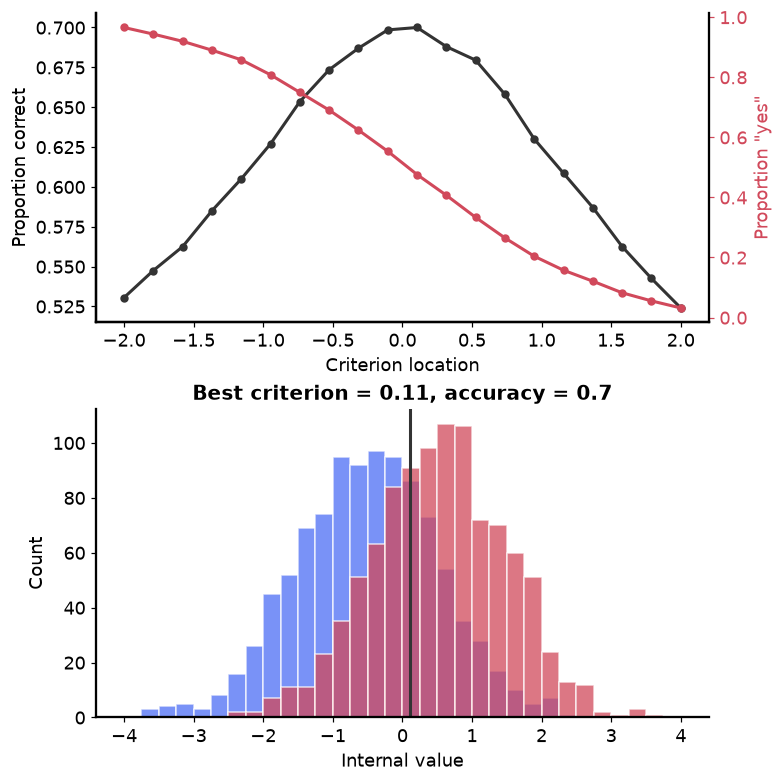

In [2]:
# what happens if we had used a different value of the criterion?
ncriteria = 20
these_criteria = np.linspace(-2, 2, ncriteria)   # 20 equally spaced values

these_proportion_correct = np.full(ncriteria, np.nan)
these_proportion_yes     = np.full(ncriteria, np.nan)

for ci in range(ncriteria):
    c = these_criteria[ci]
    these_proportion_correct[ci] = (np.sum(noise_samps <= c) + np.sum(signal_samps > c)) / ntrials
    these_proportion_yes[ci]     = (np.sum(noise_samps >  c) + np.sum(signal_samps > c)) / ntrials

# which criterion maximises accuracy?
which_criterion  = np.argmax(these_proportion_correct)
best_criterion   = these_criteria[which_criterion]
maximum_accuracy = these_proportion_correct[which_criterion]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), constrained_layout=True)

# top: accuracy and proportion 'yes' as the criterion moves
ax1.plot(these_criteria, these_proportion_correct, color=CRIT, lw=2)
ax1.scatter(these_criteria, these_proportion_correct, 20, color=CRIT)
ax1.set_xlabel("Criterion location")
ax1.set_ylabel("Proportion correct")

axr = ax1.twinx()
axr.spines["right"].set_visible(True)
axr.plot(these_criteria, these_proportion_yes, color=SIGNAL, lw=2)
axr.scatter(these_criteria, these_proportion_yes, 20, color=SIGNAL)
axr.set_ylabel('Proportion "yes"', color=SIGNAL)
axr.tick_params(axis="y", colors=SIGNAL)

# bottom: the distributions with the BEST criterion marked
bins = np.arange(np.floor(min(noise_samps.min(), signal_samps.min())),
                 np.ceil(max(noise_samps.max(), signal_samps.max())) + 0.25, 0.25)
ax2.hist(noise_samps,  bins=bins, color=NOISE,  alpha=0.75, edgecolor="white")
ax2.hist(signal_samps, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white")
ax2.axvline(best_criterion, color=CRIT, lw=2)
ax2.set_xlabel("Internal value")
ax2.set_ylabel("Count")
ax2.set_title(f"Best criterion = {best_criterion:.2g}, accuracy = {maximum_accuracy:.2g}")
plt.show()
